In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


Epoch 1/10
8/8 [==============================] - 5s 452ms/step - loss: 1.2195 - accuracy: 0.5085 - val_loss: 0.7066 - val_accuracy: 0.7627
Epoch 2/10
8/8 [==============================] - 3s 380ms/step - loss: 0.7495 - accuracy: 0.7119 - val_loss: 0.4699 - val_accuracy: 0.8814
Epoch 3/10
8/8 [==============================] - 3s 370ms/step - loss: 0.5966 - accuracy: 0.7924 - val_loss: 0.4460 - val_accuracy: 0.8136
Epoch 4/10
8/8 [==============================] - 3s 370ms/step - loss: 0.4848 - accuracy: 0.8051 - val_loss: 0.3897 - val_accuracy: 0.8814
Epoch 5/10
8/8 [==============================] - 3s 395ms/step - loss: 0.3973 - accuracy: 0.8263 - val_loss: 0.3544 - val_accuracy: 0.8983
Epoch 6/10
8/8 [==============================] - 3s 397ms/step - loss: 0.3169 - accuracy: 0.9068 - val_loss: 0.3351 - val_accuracy: 0.8814
Epoch 7/10
8/8 [==============================] - 3s 381ms/step - loss: 0.2840 - accuracy: 0.8983 - val_loss: 0.4128 - val_accuracy: 0.8475
Epoch 8/10
8/8 [====

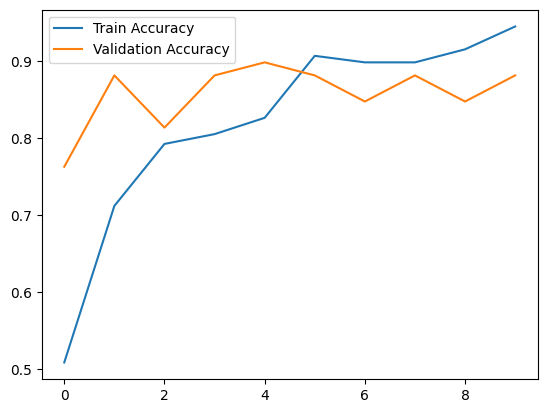

2/2 [==============================] - 0s 71ms/step - loss: 0.4009 - accuracy: 0.8814
Test Accuracy: 88.14%


C:\Users\Ajay\crazy\anaconda3\envs\projectenv\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [2]:
# Load dataset
data_dir = "dataset"
categories = ["no", "yes", "unsupported"]  # 3 classes now

data = []
labels = []
img_size = 128

for category in categories:
    folder_path = os.path.join(data_dir, category)
    for img in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img)
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img_array = cv2.resize(img_array, (img_size, img_size))
            data.append(img_array)
            labels.append(categories.index(category))
        except Exception as e:
            pass

data = np.array(data).reshape(-1, img_size, img_size, 1)
data = data / 255.0
labels = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)
y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # Output layer adjusted to 3 classes
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

model.save('brain_tumor_model.h5')

